# Telco Customer Churn — EDA


Dataset Description

Source: Kaggle – Telco Customer Churn (https://www.kaggle.com/datasets/blastchar/telco-customer-churn)

Rows: 7,043 customers

Columns: 21 features (categorical and numerical)

Target: Churn (Yes / No)

Each row represents one customer, and each column provides demographic, account, or service-related information.

Objectives

Explore and visualize the data to understand churn patterns



# 1.Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Stats
from scipy import stats

# Display settings
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)
pd.set_option('display.max_columns', 50)
pd.set_option('display.float_format', '{:.3f}'.format)

print("Libraries loaded successfully.")


Libraries loaded successfully.


# 2 · Data Loading & Exploration

In this section we load the dataset , inspect its shape, data types, statistical summary , missing values and distributions
Then we perform initial visualizations to understand distributions and relationships relevant to churn.

Visualise key patterns to guide preprocessing:

- Shape, dtypes, statistical summary
- Missing values and blank strings
- Class imbalance
- Numeric feature distributions, outliers, and skewness
- Categorical feature value counts and churn rates per category
- Correlations and multicollinearity between features
    
     

## 2.1 Load Dataset

In [2]:
!unzip archive.zip

Archive:  archive.zip
  inflating: WA_Fn-UseC_-Telco-Customer-Churn.csv  


In [3]:
!ls

archive.zip  sample_data  WA_Fn-UseC_-Telco-Customer-Churn.csv


In [4]:

file_path = '/content/WA_Fn-UseC_-Telco-Customer-Churn.csv'


df = pd.read_csv(file_path)
print(f"Dataset loaded — shape: {df.shape}")
df.head()


Dataset loaded — shape: (7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.850,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.950,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.850,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.300,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.700,151.65,Yes


## 2.2 Shape, Data Types & Statistical Summary

In [6]:

print(f"Rows: {df.shape[0]:,}  |  Columns: {df.shape[1]}")


print("\nData types and non-null counts ")
print(df.info())

print("\nStatistical summary (numeric columns) ")
print(df.describe())

print("\nTarget (Churn) value counts ")
print(df['Churn'].value_counts())
print(df['Churn'].value_counts(normalize=True).rename('proportion').round(4))


Rows: 7,043  |  Columns: 21

Data types and non-null counts 
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-n

Insights

Data types: many features are object (18 columns), only 2 int64 and 1 float64. So a large number of categorical/text fields.

The TotalCharges column is of type object (should be numeric) — others show numeric types correctly.
— This suggests “TotalCharges” has values that pandas couldn’t parse as numeric (strings, blanks).


The target Churn has counts: No = 5,174; Yes = 1,869. That’s ~26.5% churn rate. So classes are imbalanced (No is ~73.5%, Yes ~26.5).

SeniorCitizen is numeric but actually categorical (0/1).

Because many features are categorical, encoding will be required.

## 2.3 Fix TotalCharges Type & Identify Invalid Entries

In [7]:
# Convert to numeric — whitespace/blank entries become NaN
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

invalid_count = df['TotalCharges'].isnull().sum()
print(f"Invalid (non-numeric) entries in TotalCharges: {invalid_count}")
print("\nRows with TotalCharges = NaN:")
print(df[df['TotalCharges'].isnull()][['tenure', 'MonthlyCharges', 'TotalCharges']])


Invalid (non-numeric) entries in TotalCharges: 11

Rows with TotalCharges = NaN:
      tenure  MonthlyCharges  TotalCharges
488        0          52.550           NaN
753        0          20.250           NaN
936        0          80.850           NaN
1082       0          25.750           NaN
1340       0          56.050           NaN
3331       0          19.850           NaN
3826       0          25.350           NaN
4380       0          20.000           NaN
5218       0          19.700           NaN
6670       0          73.350           NaN
6754       0          61.900           NaN


After converting TotalCharges to numeric we found 11 entries became NaN and all of them have tenure = 0 as they are new customers and have not been billed yet so in cleaning section Total Charges =0 for tenure =0.


In addiction with out converting to numeric now , visualizations  won’t correctly reflect the numerical relationship of TotalCharges

## 2.4 Missing Values & Blank Strings

In [8]:
missing = df.isnull().sum()
blank  = (df == '').sum()

print(" Missing value counts ")
print(missing[missing > 0] if missing.any() else "No missing values.")

print("\n Blank string counts ")
print(blank[blank > 0] if blank.any() else "No blank strings found.")


 Missing value counts 
TotalCharges    11
dtype: int64

 Blank string counts 
No blank strings found.


Missing values in TotalCharges already shown above in 2.3

## 2.5 Target Distribution & Class Imbalance

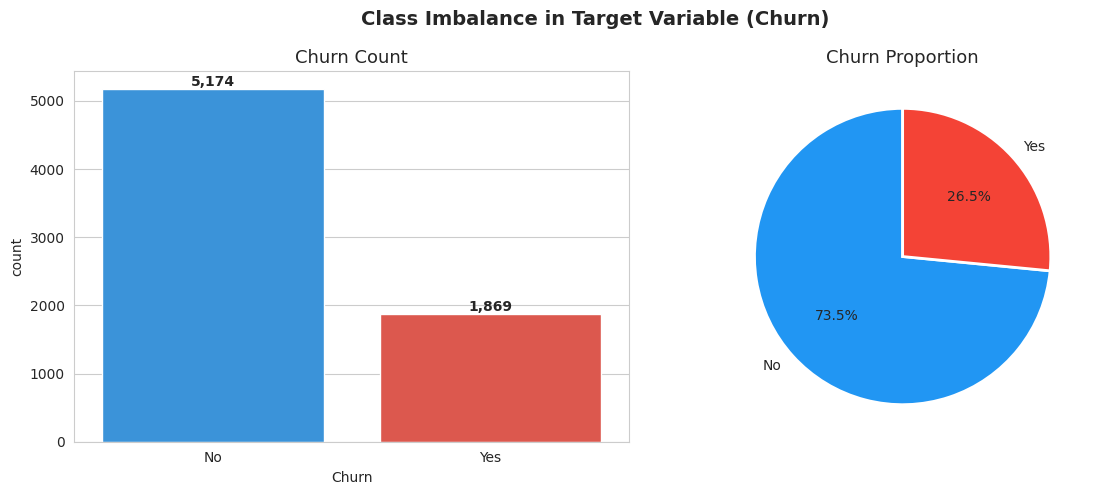

Imbalance ratio (No:Yes) ≈ 2.77 :1


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Count plot
sns.countplot(data=df, x='Churn', palette=['#2196F3','#F44336'], ax=axes[0])
axes[0].set_title('Churn Count', fontsize=13)
for p in axes[0].patches:
    axes[0].annotate(f"{int(p.get_height()):,}",
                     (p.get_x() + p.get_width() / 2, p.get_height()),
                     ha='center', va='bottom', fontweight='bold')

# Pie chart
churn_counts = df['Churn'].value_counts()
axes[1].pie(churn_counts, labels=churn_counts.index, autopct='%1.1f%%',
            colors=['#2196F3','#F44336'], startangle=90,
            wedgeprops={'edgecolor':'white','linewidth':2})
axes[1].set_title('Churn Proportion', fontsize=13)

plt.suptitle('Class Imbalance in Target Variable (Churn)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("Imbalance ratio (No:Yes) ≈", round(churn_counts['No'] / churn_counts['Yes'], 2), ":1")


The dataset is imbalanced: about 73% “No” and 27% “Yes” churn. This imbalance can bias the model toward predicting “No churn”.

Class balancing is required for fair model performance SMOTE will be applied.


## 2.6 Numeric Feature Distributions & Outlier Detection

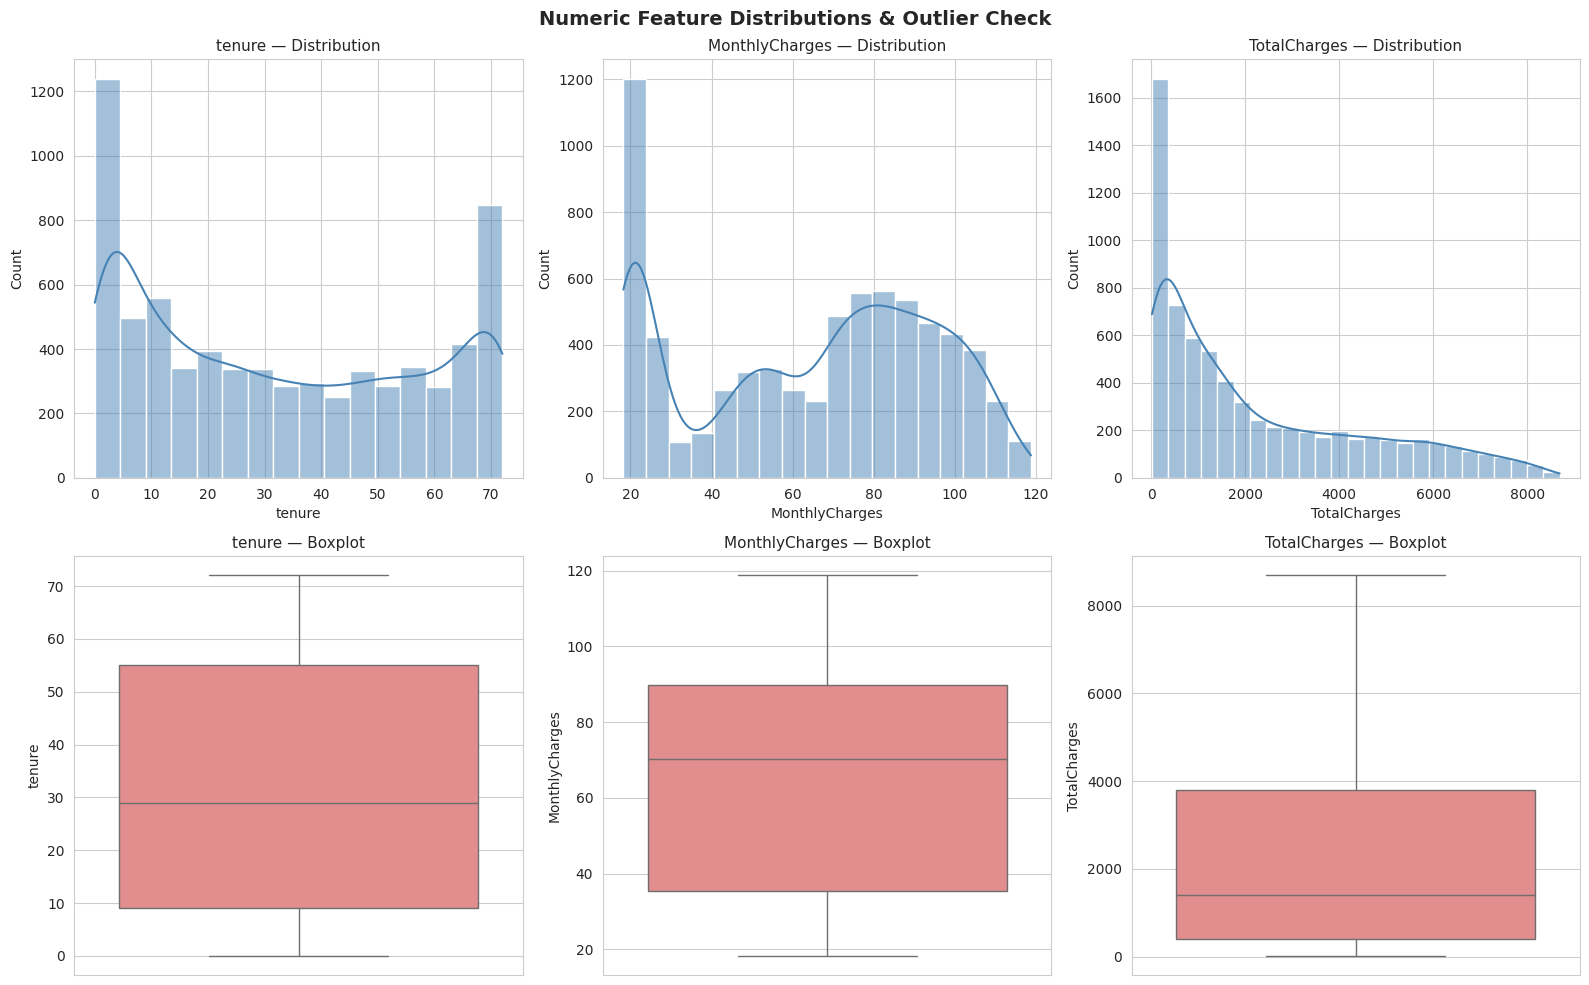

 Skewness 
  tenure: 0.240
  MonthlyCharges: -0.221
  TotalCharges: 0.962

 Kurtosis 
  tenure: -1.387
  MonthlyCharges: -1.257
  TotalCharges: -0.232


In [10]:
numeric_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']

fig, axes = plt.subplots(2, 3, figsize=(16, 10))

for i, col in enumerate(numeric_cols):
    # Histogram + KDE
    sns.histplot(df[col].dropna(), kde=True, ax=axes[0, i], color='steelblue')
    axes[0, i].set_title(f'{col} — Distribution', fontsize=11)
    axes[0, i].set_xlabel(col)

    # Boxplot
    sns.boxplot(y=df[col], ax=axes[1, i], color='lightcoral')
    axes[1, i].set_title(f'{col} — Boxplot', fontsize=11)

plt.suptitle('Numeric Feature Distributions & Outlier Check', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print(" Skewness ")
for col in numeric_cols:
    print(f"  {col}: {df[col].skew():.3f}")

print("\n Kurtosis ")
for col in numeric_cols:
    print(f"  {col}: {df[col].kurtosis():.3f}")



- tenure: right-skewed slightly; bimodal (peaks at 0–1 yr and 5–6 yr). No extreme outliers.
- MonthlyCharges: mild left skew; values range ~18–118. No outliers.
- TotalCharges: right-skewed (skew ≈ 0.96) because new customers have near-zero totals; no true outliers — this is natural business logic.
- Skew values < 1 for tenure and MonthlyCharges — StandardScaler sufficient.  
- TotalCharges skew ~0.96 — acceptable for tree-based models; log-transform beneficial for linear models.
- No extreme outliers — no capping/trimming needed.


## 2.7 Normality Tests (Shapiro-Wilk on sample)

In [11]:
# Shapiro-Wilk is limited to n ≤ 5000; we sample 500 rows
sample = df.sample(500, random_state=42)

print(" Shapiro-Wilk Normality Test (H0: data is normally distributed) ")
print(f"{'Feature':<20} {'Statistic':>10} {'p-value':>12} {'Normal?':>10}")
print("-" * 56)
for col in ['tenure', 'MonthlyCharges', 'TotalCharges']:
    stat, p = stats.shapiro(sample[col].dropna())
    normal = "Yes" if p > 0.05 else "No"
    print(f"{col:<20} {stat:>10.4f} {p:>12.6f} {normal:>10}")




 Shapiro-Wilk Normality Test (H0: data is normally distributed) 
Feature               Statistic      p-value    Normal?
--------------------------------------------------------
tenure                   0.8983     0.000000         No
MonthlyCharges           0.9157     0.000000         No
TotalCharges             0.8560     0.000000         No


All three fail normality — consistent with skewed distributions observed above.
StandardScaler is appropriate (does not assume normality).


## 2.8 Numeric Features by Churn Status

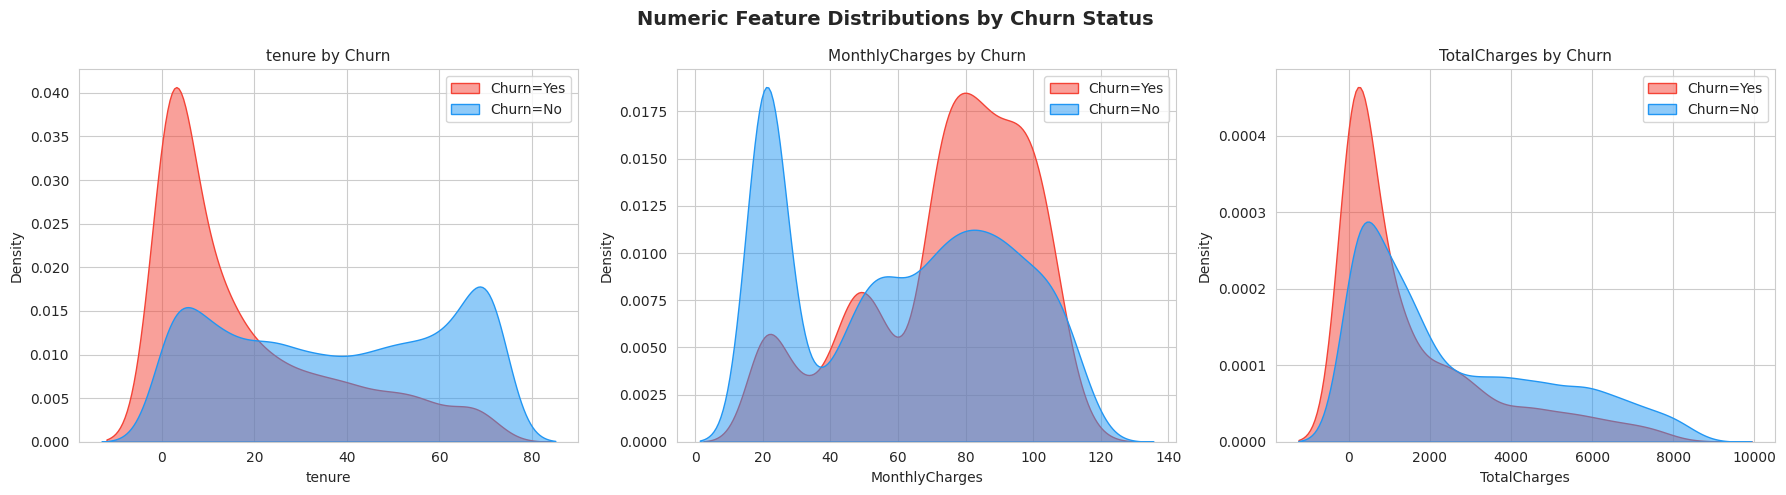

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for i, col in enumerate(numeric_cols):
    for label, color in [('Yes', '#F44336'), ('No', '#2196F3')]:
        sns.kdeplot(data=df[df['Churn'] == label], x=col, fill=True,
                    label=f'Churn={label}', alpha=0.5, ax=axes[i], color=color)
    axes[i].set_title(f'{col} by Churn', fontsize=11)
    axes[i].set_xlabel(col)
    axes[i].legend()

plt.suptitle('Numeric Feature Distributions by Churn Status', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


Insights:

tenure: lower for churned customers (they tend to leave early).

MonthlyCharges: slightly higher for churned customers (higher plans lead to higher churn).

TotalCharges: lower for churned customers (less time means lower totals).


## 2.9 Correlation & Multicollinearity Analysis

                tenure  MonthlyCharges  TotalCharges
tenure           1.000           0.248         0.826
MonthlyCharges   0.248           1.000         0.651
TotalCharges     0.826           0.651         1.000


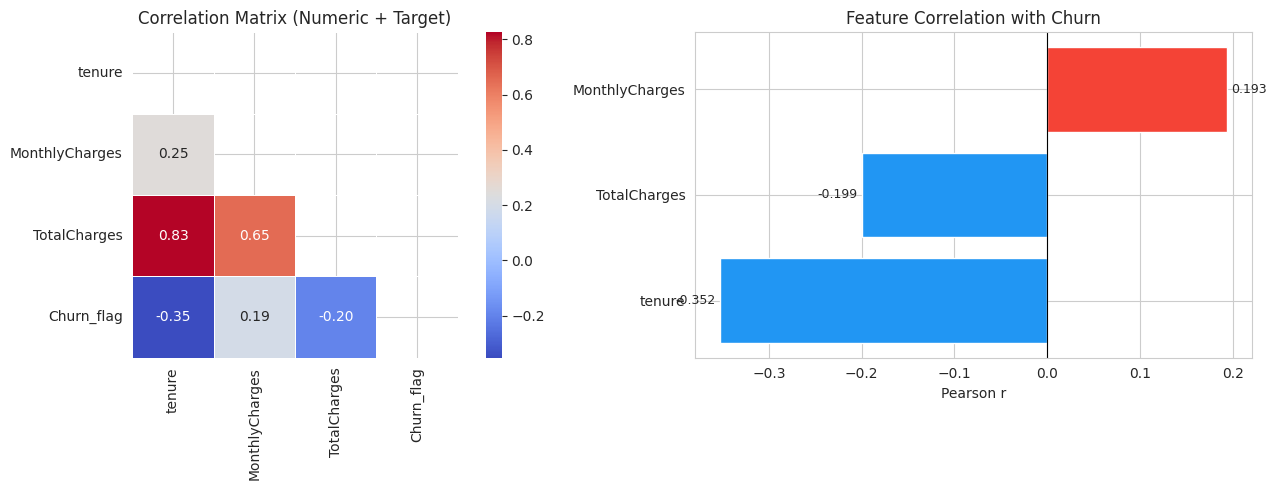

 Correlation with Churn 
tenure           -0.352
TotalCharges     -0.199
MonthlyCharges    0.193


In [13]:
df_corr = df.copy()
df_corr['Churn_flag'] = df_corr['Churn'].map({'Yes': 1, 'No': 0})

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Correlation heatmap
corr_matrix = df_corr[['tenure', 'MonthlyCharges', 'TotalCharges', 'Churn_flag']].corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap='coolwarm',
            square=True, linewidths=0.5, ax=axes[0], mask=mask)
axes[0].set_title('Correlation Matrix (Numeric + Target)', fontsize=12)

corr = df[['tenure','MonthlyCharges','TotalCharges']].corr()
print(corr)

# Correlation with Churn bar chart
corr_target = corr_matrix['Churn_flag'].drop('Churn_flag').sort_values()
colors = ['#F44336' if v > 0 else '#2196F3' for v in corr_target]
axes[1].barh(corr_target.index, corr_target.values, color=colors)
axes[1].axvline(0, color='black', linewidth=0.8)
axes[1].set_title('Feature Correlation with Churn', fontsize=12)
axes[1].set_xlabel('Pearson r')
for i, (val, label) in enumerate(zip(corr_target.values, corr_target.index)):
    axes[1].text(val + 0.005 if val >= 0 else val - 0.005, i, f"{val:.3f}",
                 va='center', ha='left' if val >= 0 else 'right', fontsize=9)

plt.tight_layout()
plt.show()

print(" Correlation with Churn ")
print(corr_target.to_string())


In [ ]:

# Select categorical columns only (exclude target)
cat_cols = df.select_dtypes(include='object').columns.drop('Churn')

# One-hot encode (better than label encoding for Chi2)
X_cat = pd.get_dummies(df[cat_cols], drop_first=True)

y = df_corr['Churn_flag']  # reuse what you already created

# Apply Chi-square
chi_scores, p_values = chi2(X_cat, y)

chi_results = pd.DataFrame({
    'Feature': X_cat.columns,
    'Chi2 Score': chi_scores,
    'p-value': p_values
}).sort_values(by='Chi2 Score', ascending=False)

print("\n Chi-square Results (Categorical Features) ")
print(chi_results.head(15))


── Chi-square Results (Categorical Features) ──
                                   Feature  Chi2 Score  p-value
7063                     Contract_Two year     488.578    0.000
7066        PaymentMethod_Electronic check     426.423    0.000
7048           InternetService_Fiber optic     374.476    0.000
7052      OnlineBackup_No internet service     286.520    0.000
7060   StreamingMovies_No internet service     286.520    0.000
7049                    InternetService_No     286.520    0.000
7058       StreamingTV_No internet service     286.520    0.000
7056       TechSupport_No internet service     286.520    0.000
7050    OnlineSecurity_No internet service     286.520    0.000
7054  DeviceProtection_No internet service     286.520    0.000
7062                     Contract_One year     176.123    0.000
7051                    OnlineSecurity_Yes     147.296    0.000
7057                       TechSupport_Yes     135.560    0.000
7044                        Dependents_Yes     133.036 

In [ ]:
significant_cat = chi_results[chi_results['p-value'] < 0.05]

print("\n Significant Categorical Features ")
print(significant_cat['Feature'].tolist())


── Significant Categorical Features ──
['Contract_Two year', 'PaymentMethod_Electronic check', 'InternetService_Fiber optic', 'OnlineBackup_No internet service', 'StreamingMovies_No internet service', 'InternetService_No', 'StreamingTV_No internet service', 'TechSupport_No internet service', 'OnlineSecurity_No internet service', 'DeviceProtection_No internet service', 'Contract_One year', 'OnlineSecurity_Yes', 'TechSupport_Yes', 'Dependents_Yes', 'PaperlessBilling_Yes', 'PaymentMethod_Credit card (automatic)', 'Partner_Yes', 'PaymentMethod_Mailed check', 'OnlineBackup_Yes', 'DeviceProtection_Yes', 'StreamingTV_Yes', 'StreamingMovies_Yes', 'MultipleLines_Yes']


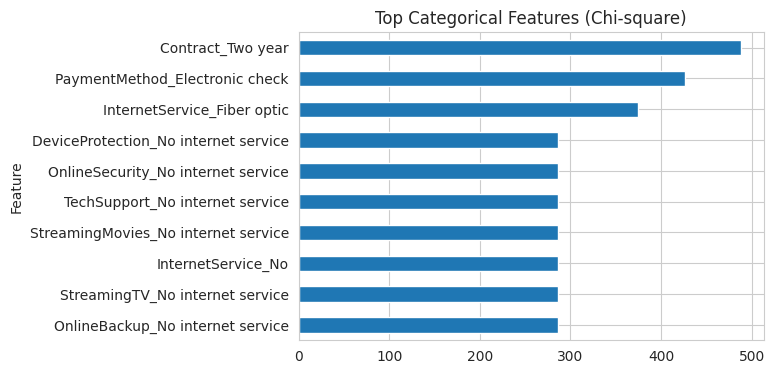

In [ ]:
chi_results.head(10).sort_values('Chi2 Score').plot(
    kind='barh', x='Feature', y='Chi2 Score', legend=False, figsize=(6,4)
)
plt.title("Top Categorical Features (Chi-square)")
plt.show()

Interpretation:

tenure ↔ TotalCharges  = 0.83 → very strong correlation.

MonthlyCharges ↔ TotalCharges = 0.65 → moderate correlation.

tenure ↔ MonthlyCharges = 0.25 → weak correlation.

Conclusion:
TotalCharges is largely redundant with tenure. For models sensitive to multicollinearity we can drop TotalCharges


## 2.10 Categorical Feature Analysis

In [14]:
categorical_cols = [c for c in df.select_dtypes(include='object').columns
                    if c not in ['customerID', 'Churn']]

print(f"Categorical columns ({len(categorical_cols)}): {categorical_cols}")
print()

for col in categorical_cols:
    print(f" {col}   ({df[col].nunique()} unique values)")
    print(df[col].value_counts().to_string())
    print()


Categorical columns (15): ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']

 gender   (2 unique values)
gender
Male      3555
Female    3488

 Partner   (2 unique values)
Partner
No     3641
Yes    3402

 Dependents   (2 unique values)
Dependents
No     4933
Yes    2110

 PhoneService   (2 unique values)
PhoneService
Yes    6361
No      682

 MultipleLines   (3 unique values)
MultipleLines
No                  3390
Yes                 2971
No phone service     682

 InternetService   (3 unique values)
InternetService
Fiber optic    3096
DSL            2421
No             1526

 OnlineSecurity   (3 unique values)
OnlineSecurity
No                     3498
Yes                    2019
No internet service    1526

 OnlineBackup   (3 unique values)
OnlineBackup
No                     3088
Yes            

## 2.11 Churn Rate per Categorical Feature (Bar Charts)

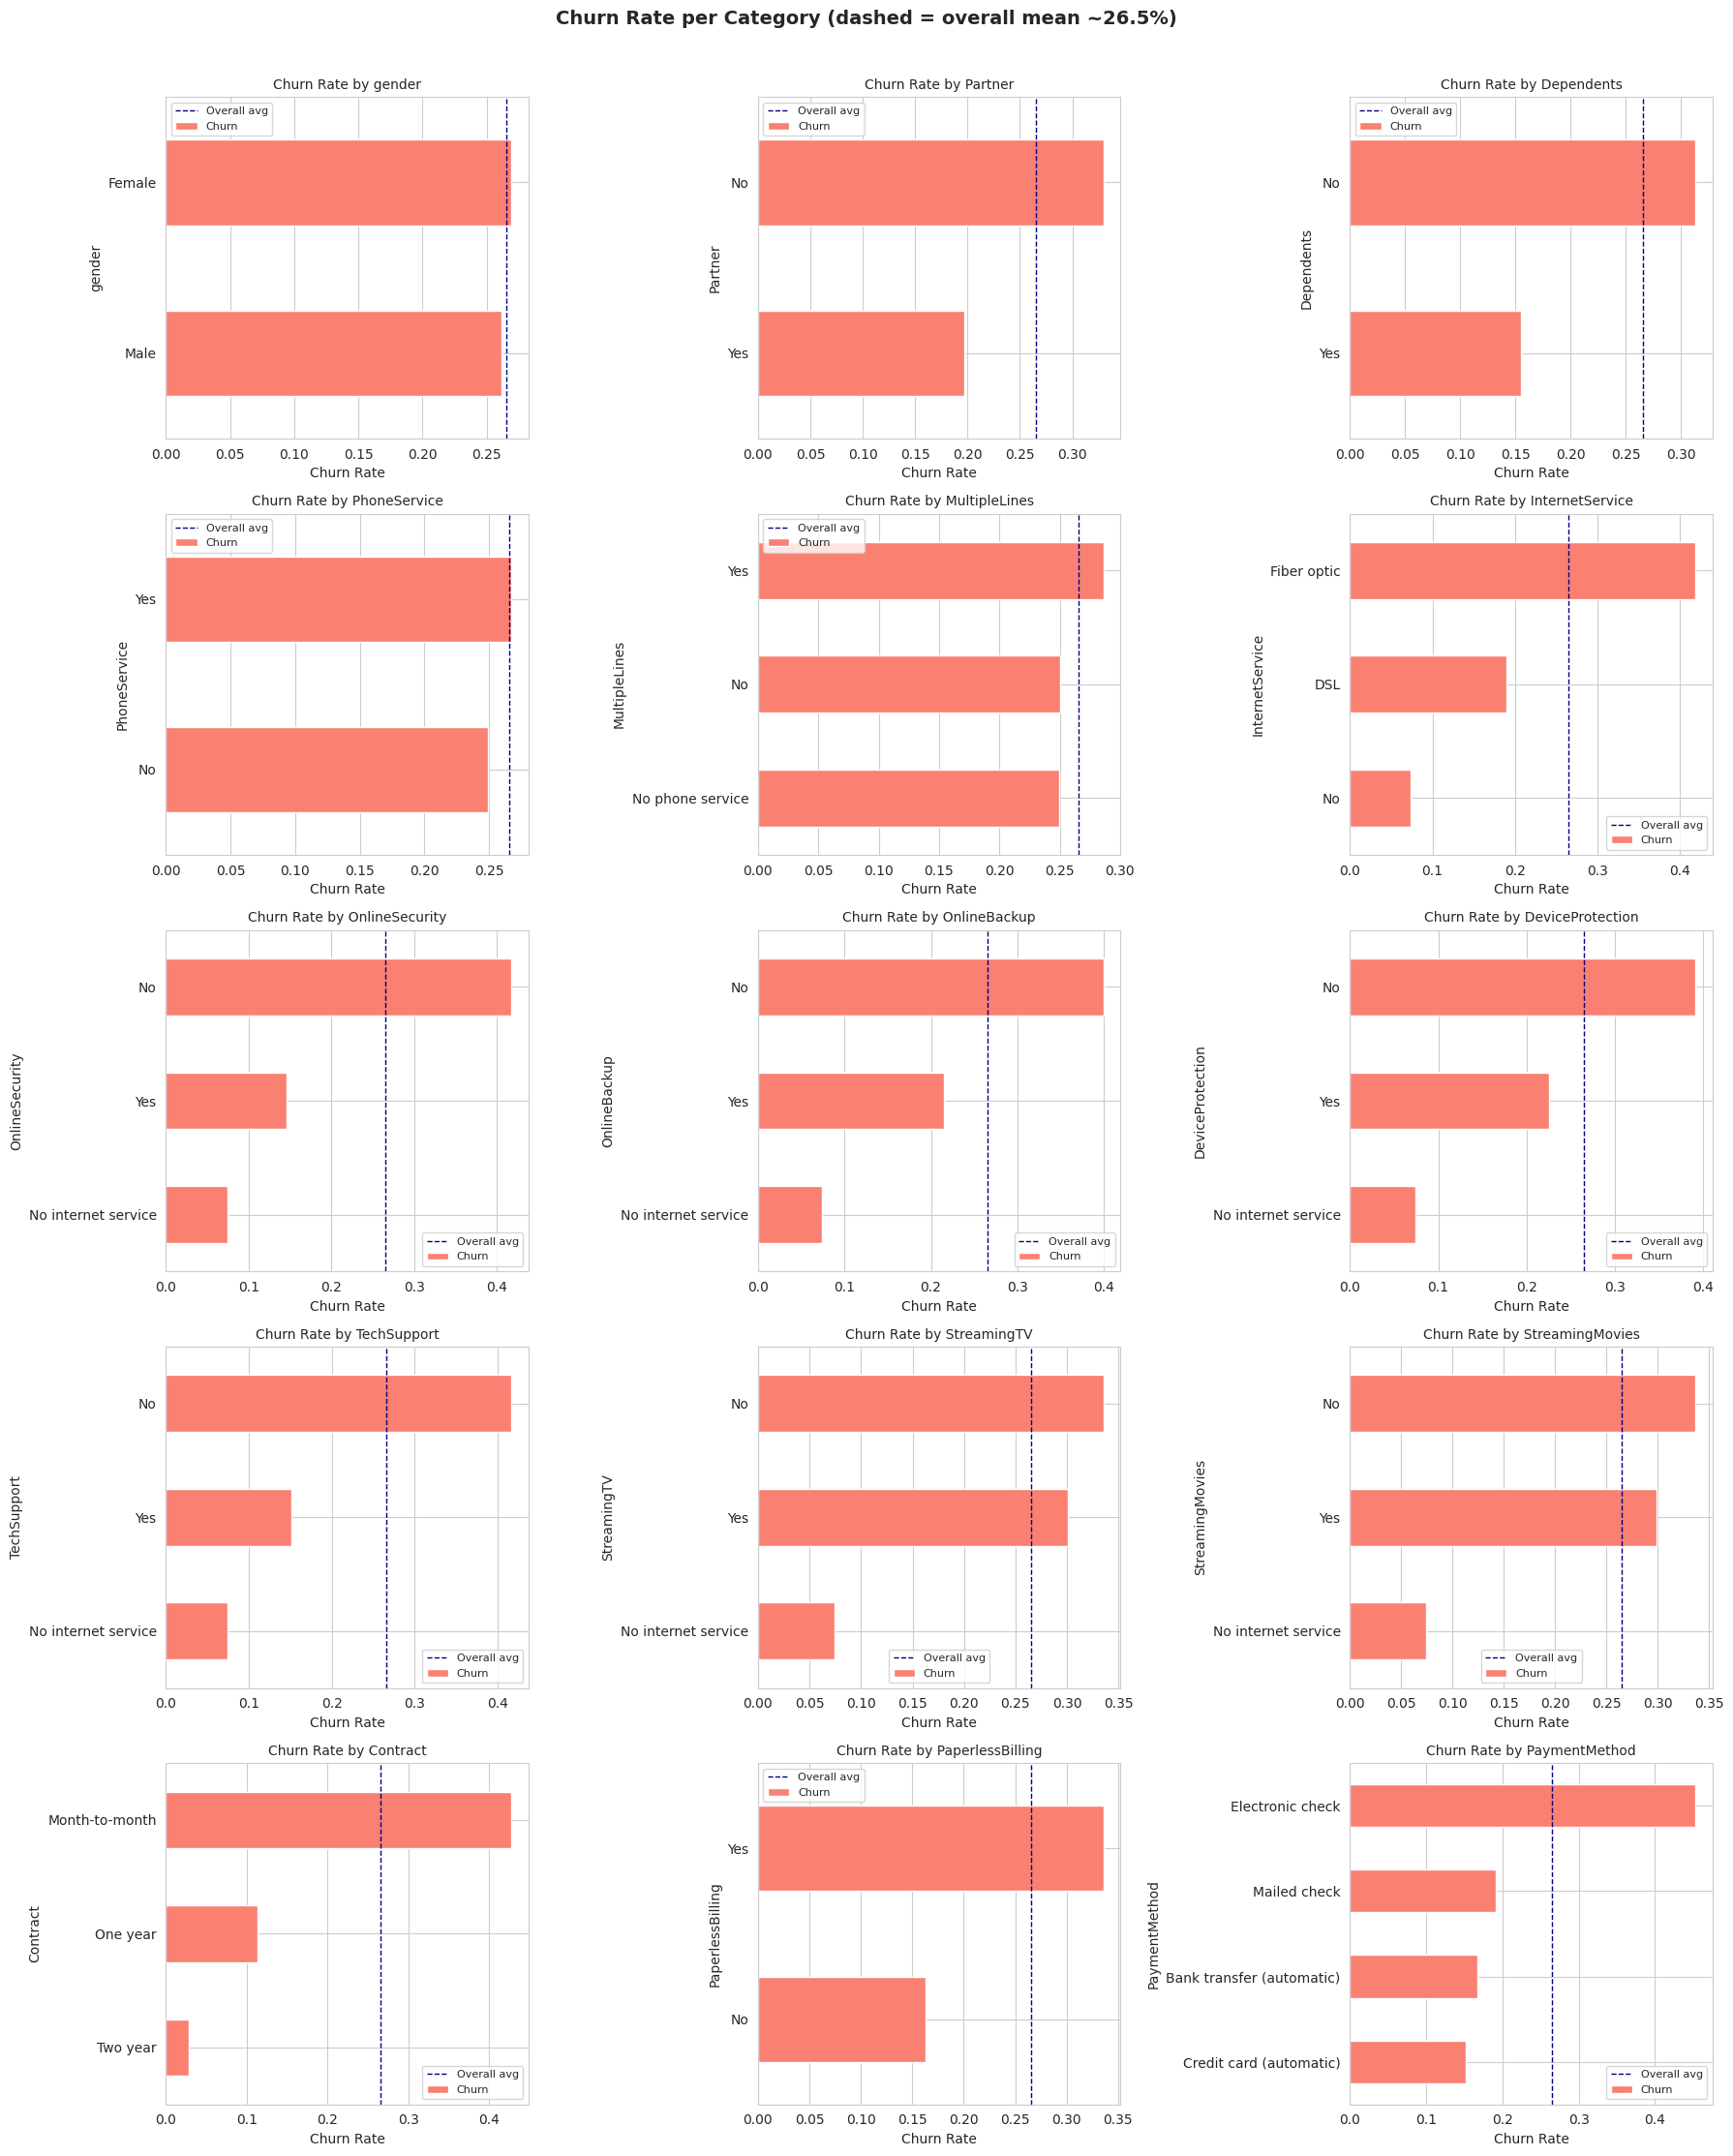

In [ ]:
fig, axes = plt.subplots(5, 3, figsize=(18, 22))
axes = axes.flatten()

categorical_cols = ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines',
                    'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
                    'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract',
                    'PaperlessBilling', 'PaymentMethod']

for i, col in enumerate(categorical_cols):
    churn_rate = df.groupby(col)['Churn'].apply(lambda x: (x == 'Yes').mean())
    churn_rate.sort_values().plot(kind='barh', ax=axes[i], color='salmon', edgecolor='white')
    axes[i].set_title(f'Churn Rate by {col}', fontsize=10)
    axes[i].set_xlabel('Churn Rate')
    axes[i].axvline(df['Churn'].eq('Yes').mean(), color='navy', linestyle='--', linewidth=1,
                    label='Overall avg')
    axes[i].legend(fontsize=8)

plt.suptitle('Churn Rate per Category (dashed = overall mean ~26.5%)',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()


Key findings from categorical churn rates:

Customers on month-to-month contracts show a very high churn rate 43%, while two-year contracts have extremely low churn 3%, making contract type the strongest predictor.


Users with fiber optic internet service churn significantly more 42% compared to DSL users 19%.


Lack of online security or tech support is strongly associated with churn 42%, whereas customers with these services churn much less 15%.


Customers using paperless billing tend to churn more 33% compared to those using paper billing 16%.


The electronic check payment method has the highest churn rate around 45%, indicating it is a high-risk payment behavior.


Senior citizens churn more frequently 42% compared to non-seniors 24%.


Gender shows almost no meaningful difference in churn, indicating it has little to no predictive value.




## 2.12 SeniorCitizen Churn Analysis

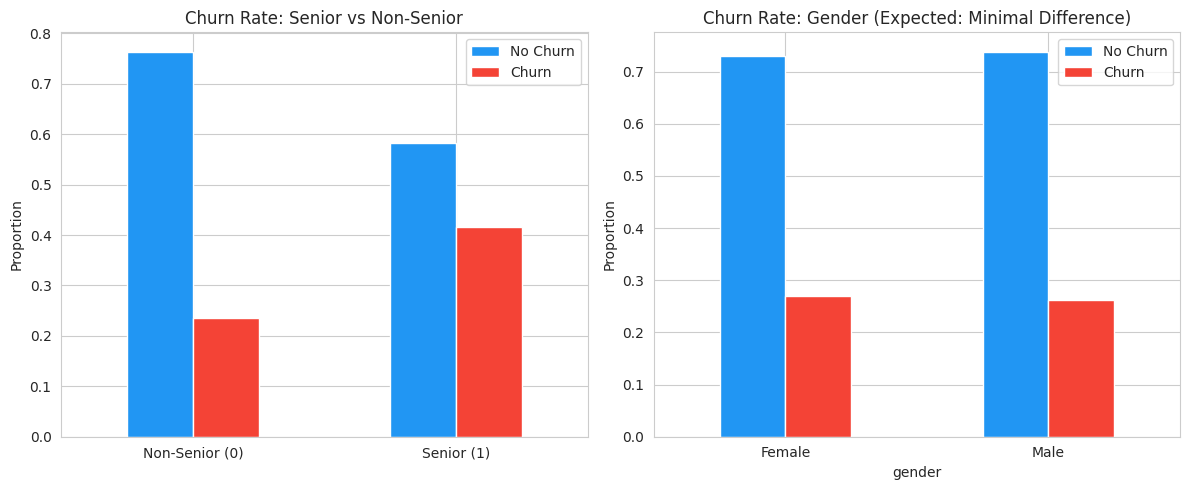

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

senior_churn = df.groupby('SeniorCitizen')['Churn'].value_counts(normalize=True).unstack()
senior_churn.index = ['Non-Senior (0)', 'Senior (1)']
senior_churn.plot(kind='bar', ax=axes[0], color=['#2196F3','#F44336'], rot=0)
axes[0].set_title('Churn Rate: Senior vs Non-Senior')
axes[0].set_ylabel('Proportion')
axes[0].legend(['No Churn', 'Churn'])

# Gender — minimal effect
gender_churn = df.groupby('gender')['Churn'].value_counts(normalize=True).unstack()
gender_churn.plot(kind='bar', ax=axes[1], color=['#2196F3','#F44336'], rot=0)
axes[1].set_title('Churn Rate: Gender (Expected: Minimal Difference)')
axes[1].set_ylabel('Proportion')
axes[1].legend(['No Churn', 'Churn'])

plt.tight_layout()
plt.show()


SeniorCitizen: 42% churn rate vs 24% for non-seniors — significant difference.

Gender: 26% churn for both Male and Female — confirms gender is a weak predictor.  

Feature importance from models may suggest dropping gender later.


Insight:

customerID: unique for every row, not predictive so will drop it

Binary Features

gender, Partner, Dependents, PhoneService, PaperlessBilling: two categories only.
Action: label encode (Yes/No → 1/0).

Three-Category Features (Ordinal-like or Nominal)

MultipleLines, OnlineSecurity, OnlineBackup,
DeviceProtection, TechSupport, StreamingTV, StreamingMovies.

Most have "No internet service" or "No phone service" so Combine "No internet service" and "No phone service" into "No".Then one-hot encode (pd.get_dummies).

Multi-Class Nominal Feature

PaymentMethod ,InternetService ,Contract

Churn relation observations

Contract: strong effect (shorter contract → higher churn).

InternetService and its dependent services (OnlineSecurity, TechSupport, etc.) show clear churn differences, so keep all.

gender has minimal effect, but retain for completeness.